<a href="https://colab.research.google.com/github/LaerteKimura/FIAP_trabalho_ML_Diagnostico/blob/main/FIAP_trabalho_ML_Diagnostico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **POSTECH - IA para Devs - Tech Challenge - Fase 1**

**GRUPO 63**

*   Felipe Demétrius Martins da Silva - RM 367962
*   Kauê Bove Martins - RM 367999
*   Laerte Kimura - RM 368091
*   Thiago Albuquerque Rosa - RM 366838
*   Vinicius Otavio Soares da Silva - RM 367861

**DATASET**

Para o presente trabalho, o grupo escolheu um dos datasets sugeridos no próprio enunciado do Tech Challenge: o [Diabetes Data Set](https://www.kaggle.com/datasets/mathchi/diabetes-data-set/data), disponível no Kaggle (autor: mathchi).

Esse conjunto de dados foi originalmente coletado pelo **National Institute of Diabetes and Digestive and Kidney Diseases** e contém **768 registros de pacientes**, com informações clínicas e fisiológicas relacionadas ao diagnóstico de **diabetes tipo 2**.

O objetivo principal é **prever se um paciente tem ou não diabetes**, a partir de medidas coletadas em exames de rotina.
A variável alvo é `Outcome`, que assume valor **1** para pacientes com diagnóstico positivo e **0** para negativos.


**Atributos do dataset**

O conjunto de dados contém 8 atributos de entrada e 1 atributo alvo (`Outcome`):

| Coluna                       | Descrição                                                           |
| :--------------------------- | :------------------------------------------------------------------ |
| **Pregnancies**              | Número de vezes que a paciente ficou grávida.                       |
| **Glucose**                  | Nível de glicose no sangue após teste oral de tolerância à glicose. |
| **BloodPressure**            | Pressão arterial diastólica (em mm Hg).                             |
| **SkinThickness**            | Espessura da dobra cutânea do tríceps (em mm).                      |
| **Insulin**                  | Nível de insulina sérica em jejum (mu U/ml).                        |
| **BMI**                      | Índice de massa corporal (peso em kg dividido pela altura em m²).   |
| **DiabetesPedigreeFunction** | Mede a predisposição genética para diabetes.                        |
| **Age**                      | Idade da paciente (em anos).                                        |
| **Outcome**                  | Variável alvo (0 = não possui diabetes, 1 = possui diabetes).       |


Importando as bibliotecas necessárias para o projeto

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_curve, auc, accuracy_score
from sklearn import metrics

Definindo funções auxiliares para apoiar a análise

In [22]:
def plotHistogram(values, label, feature, title):
    sns.set_style("whitegrid")
    plotOne = sns.FacetGrid(values, hue=label, aspect=2)
    plotOne.map(sns.histplot, feature, kde=False)
    plotOne.set(xlim=(0, values[feature].max()))
    plotOne.add_legend()
    plotOne.set_axis_labels(feature, 'Proportion')
    plotOne.fig.suptitle(title)
    plt.show()

def plot_knn_error_rates(X_train_scaled, X_test_scaled, Y_train, Y_test, k_range, title):
    """
    Calculates and plots the error rate for different K values in KNN.

    Args:
        X_train_scaled: Scaled training features.
        X_test_scaled: Scaled test features.
        Y_train: Training target.
        Y_test: Test target.
        k_range: A range of K values to test.
        title: The title for the plot.
    """
    error_rates = []
    for i in k_range:
        knn = KNeighborsClassifier(n_neighbors=i)
        knn.fit(X_train_scaled, Y_train)
        pred_i = knn.predict(X_test_scaled)
        error_rates.append(np.mean(pred_i != Y_test))

    plt.figure(figsize=(12, 6))
    plt.plot(k_range, error_rates, color='red', linestyle='dashed', marker='o',
             markerfacecolor='blue', markersize=10)
    plt.title(title)
    plt.xlabel('K Value')
    plt.ylabel('Mean Error')
    plt.show()

**IMPORTAÇÃO DO DATASET**

Importando o dataset a partir do mesmo diretório utilizando a biblioteca **pandas**

In [42]:
data = pd.read_csv("diabetes_dataset.csv")

**Visualização e informações iniciais**

Verificando a importação dos dados, exibindo as primeiras linhas e as informações básicas do dataset


In [ ]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
data.shape

(768, 9)

In [6]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Verificando a informação do dataset e os datatypes das colunas

In [7]:
data.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


**Distribuição dos dados em relação à variável alvo (`Outcome`)**

Analisando a distribuição dos dados em relação à variável alvo (`Outcome`)

In [8]:
data.groupby("Outcome").describe()

Pregnancies                                                Glucose  \
              count      mean       std  min   25%  50%  75%   max   count   
Outcome                                                                      
0             500.0  3.298000  3.017185  0.0  1.00  2.0  5.0  13.0   500.0   
1             268.0  4.865672  3.741239  0.0  1.75  4.0  8.0  17.0   268.0   

                     ... DiabetesPedigreeFunction           Age             \
               mean  ...                      75%    max  count       mean   
Outcome              ...                                                     
0        109.980000  ...                  0.56175  2.329  500.0  31.190000   
1        141.257463  ...                  0.72800  2.420  268.0  37.067164   

                                                  
               std   min   25%   50%   75%   max  
Outcome                                           
0        11.667655  21.0  23.0  27.0  37.0  81.0  
1        10.968254  21.0  28.0  36.0  44.0  70.0  

[2 rows x 64 columns]

In [9]:
data["Outcome"].value_counts(normalize=True)

,proportion
Outcome,
0,0.651042
1,0.348958


O resultado mostra aproximadamente 65% de pacientes não possuem diabetes (`Outcome` = 0) e 35% possuem (`Outcome` = 1), o que quer dizer que se o modelo prever "0" na variável Outcome, ele já tem 65% de acurácia, mesmo sem detectar ninguem com diabetes.

Como estamos trabalhando com o sistema de saúde, errar o diagnóstico significa classificar pessoas saudáveis como doentes, ou pior, classificar pessoas doentes, que precisam de tratamento, como saudáveis. Por este motivo, o grupo analisou as opções abaixo para tratar o desbalanceamento.

1.   Aumento da classe minoritária (`Oversampling`): teríamos que replicar os registros da classe com menos exemplos ou inventar novos exemplos, mas isso poderia criar ruídos e atrapalhar nosso processo, por isso ele não será usado.
2.   Redução da classe majoritária (`Undersampling`): teríamos que remover exemplos da classe mais frequente, mas como nosso dataset é relativamente pequeno, pode eliminar informações úteis, por isso não a usaremos.
3.   Ajuste de pesos das classes (`class_weight`): usar esta estratégia nos fará dar mais importância à classe minoritária. Desta forma, não precisamos alterar o número de amostras. Por este motivo, escolhemos essa estratégia.
4.   Ajuste de métricas de avaliação: Não poderemos olhar apenas para a acurácia por causa do desbalanceamento, por isso será fundamental avaliar o modelo com métricas adequadas, como Recall, F1-Score e AUC-ROC, mas falaremos mais disso mais tarde.



**Análise de correlação dos dados**

Analisando a correlação dos dados para entender quais têm maior relação com o diagnóstico de diabetes (`Outcome`).

In [43]:
corr = data.corr(numeric_only=True)
corr['Outcome'].abs().sort_values(ascending=False)

,Outcome
Outcome,1.000000
Glucose,0.466581
BMI,0.292695
Age,0.238356
Pregnancies,0.221898
DiabetesPedigreeFunction,0.173844
Insulin,0.130548
SkinThickness,0.074752
BloodPressure,0.065068


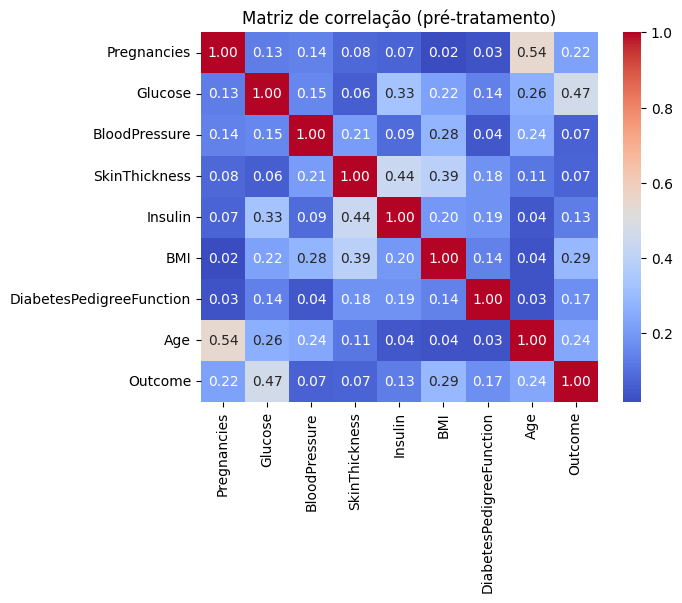

In [44]:
sns.heatmap(corr.abs(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlação (pré-tratamento)")
plt.show()

**Resultado:** observamos que as variáveis **Glucose**, **BMI**, **Age** e **Pregnancies** apresentaram maior relação com a variável alvo (`Outcome`), sendo potencialmente as mais relevantes para o modelo preditivo.

**Tratamento de dados faltantes**

Antes de prosseguir, é importante tratar valores ausentes e inconsistências.

Verificando a quantidade de valores nulos por coluna

In [45]:
print("Quantidade de valores nulos por coluna:")
data.isna().sum()

Quantidade de valores nulos por coluna:


,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


Não há valores nulos no dataset.

Verificando a quantidade de valores igual a zero por coluna.

In [46]:
print("Quantidade de valores igual a zero por coluna:")
(data == 0).sum()

Quantidade de valores igual a zero por coluna:


,0
Pregnancies,111
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,500


Filtrando colunas que tem a menos um valor igual a zero.

In [47]:
zero_columns = (data == 0).sum()
columns_with_zeros = zero_columns[zero_columns > 0]
print("\nColunas com valores zero:")
zero_columns[zero_columns > 0]


Colunas com valores zero:


,0
Pregnancies,111
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
Outcome,500


Para as variáveis fisiológicas (`Glucose`,`BloodPressure`,`SkinThickness`,`Insulin`, `BMI`) não faz sentido que possuam valor zero. Isso quer dizer que quando forem zero vamos tratar como valores faltantes. Esses valores faltantes podem confundir os algoritmos, especialmente os sensíveis à distribuição e à escala dos dados, como KNN, Regressão Logística e SVM. Por este motivo, vamos atribuir valor NaN e depois inputar o valor da mediana por coluna.

In [48]:
cols_invalid_zero = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
data[cols_invalid_zero] = data[cols_invalid_zero].replace(0, np.nan)

In [49]:
medianas = data[cols_invalid_zero].median()
data[cols_invalid_zero] = data[cols_invalid_zero].fillna(medianas)

print("\nValores ausentes após imputação (devem ser 0):")
display(data[cols_invalid_zero].isna().sum())


Valores ausentes após imputação (devem ser 0):


,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0


**Análise de correlação após o tratamento dos dados**

Após o tratamento dos valores inválidos (substituição de zeros por NaN e imputação pela mediana), realizamos novamente a análise de correlação entre as variáveis independentes e a variável alvo (`Outcome`), com o objetivo de verificar se houve alterações nos padrões observados anteriormente.

In [50]:
# Cálculo da nova matriz de correlação
corr_after = data.corr(numeric_only=True)

# Ordenando as correlações com a variável alvo
corr_after['Outcome'].abs().sort_values(ascending=False)

,Outcome
Outcome,1.000000
Glucose,0.492782
BMI,0.312038
Age,0.238356
Pregnancies,0.221898
SkinThickness,0.214873
Insulin,0.203790
DiabetesPedigreeFunction,0.173844
BloodPressure,0.165723


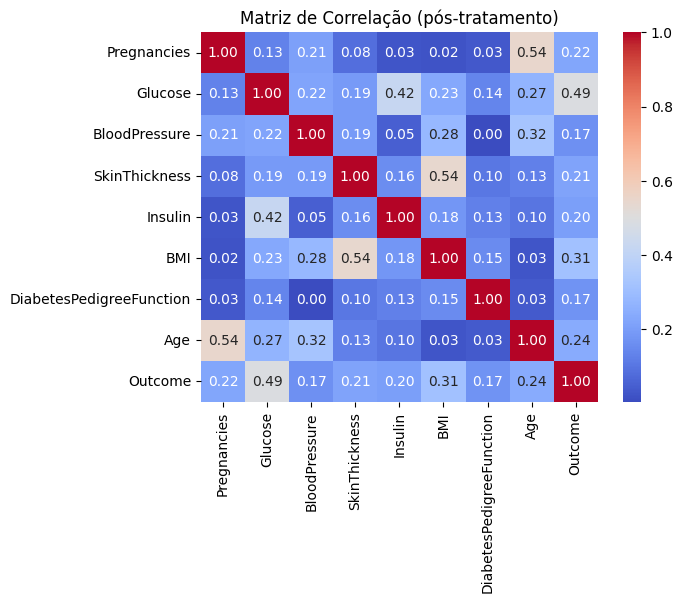

In [51]:
# Exibindo o heatmap
sns.heatmap(corr_after.abs(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlação (pós-tratamento)')
plt.show()

**Resultado da nova análise:**
Após o tratamento, observamos uma melhoria na consistência das correlações, especialmente nas variáveis fisiológicas que anteriormente continham zeros inválidos.
As variáveis **Glucose**, **BMI**, **Age** e **Pregnancies** continuam apresentando os maiores coeficientes de correlação com a variável alvo (Outcome), reforçando a importância dessas características para a construção do modelo preditivo.

A remoção dos valores inválidos eliminou a distorção causada pelos zeros artificiais, tornando as relações estatísticas mais representativas do comportamento real dos pacientes.

**Análise e tratamento de outliers**

Após o tratamento dos valores ausentes, analisamos a presença de outliers nas variáveis numéricas.
Esses valores podem representar erros de medição ou casos clínicos atípicos.
Utilizamos o método do Intervalo Interquartílico (IQR) para identificar observações fora do intervalo esperado.

In [52]:
# Método estatístico simples: IQR (Interquartile Range)
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1

# Limites para detecção
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Verificando quais colunas têm outliers
outliers = ((data < lower_bound) | (data > upper_bound)).sum()
display(outliers)


,0
Pregnancies,4
Glucose,0
BloodPressure,14
SkinThickness,87
Insulin,346
BMI,8
DiabetesPedigreeFunction,29
Age,9
Outcome,0


<Axes: >

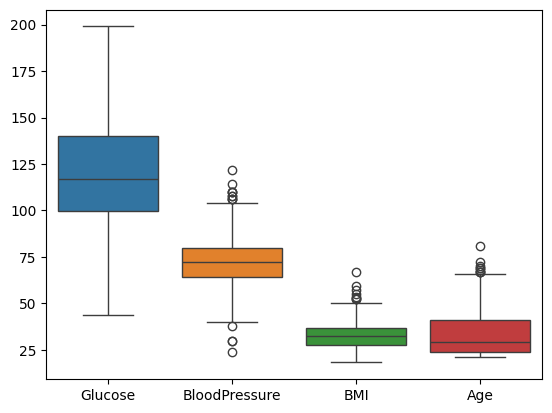

In [53]:
sns.boxplot(data=data[['Glucose','BloodPressure','BMI','Age']])

Como se trata de um dataset médico real, optamos por não remover os outliers, pois representam casos clínicos importantes.
Entretanto, valores fisiologicamente impossíveis (zeros) foram tratados como dados faltantes.
Para evitar que os outliers influenciem demais o modelo, utilizamos o RobustScaler, que é mais adequado para dados com distribuição assimétrica e valores extremos.

**KNN**

In [55]:
x = data[['Pregnancies', 'Glucose', 'BloodPressure', 'BMI', 'DiabetesPedigreeFunction', 'Age']]
y = data['Outcome']

X_temp, X_test, y_temp, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42)

print(f"Tamanho do conjunto de treino: {X_train.shape[0]} ({X_train.shape[0]/len(x)*100:.1f}%)")
print(f"Tamanho do conjunto de validação: {X_val.shape[0]} ({X_val.shape[0]/len(x)*100:.1f}%)")
print(f"Tamanho do conjunto de teste: {X_test.shape[0]} ({X_test.shape[0]/len(x)*100:.1f}%)")

Tamanho do conjunto de treino: 460 (59.9%)
Tamanho do conjunto de validação: 154 (20.1%)
Tamanho do conjunto de teste: 154 (20.1%)


In [56]:
classifier_model = KNeighborsClassifier(n_neighbors=5)
classifier_model.fit(X_train, y_train)
classifier_model.predict([[1, 148,	72,	33.6,	0.627,	50]])
y_predito = classifier_model.predict(X_test)
accuracy_score(y_true=y_test, y_pred=y_predito)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


0.7272727272727273

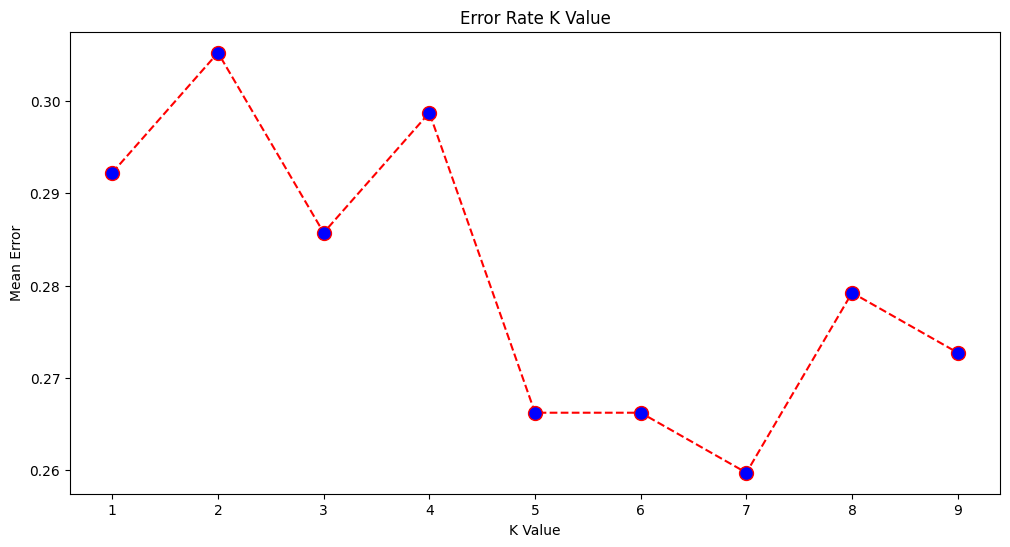

In [57]:
scaler = RobustScaler()

scaler.fit(X_train)

x_train_escalonado = scaler.transform(X_train)
x_test_escalonado = scaler.transform(X_test)

plot_knn_error_rates(X_train_scaled=x_train_escalonado, X_test_scaled=x_test_escalonado, Y_train=y_train, Y_test=y_test, k_range=range(1, 10), title='Error Rate K Value')

In [61]:
classifier_model = KNeighborsClassifier(n_neighbors=7)
classifier_model.fit(x_train_escalonado, y_train)

y_predito = classifier_model.predict(x_test_escalonado)
print(accuracy_score(y_test, y_predito))

0.7402597402597403


In [64]:
print(classification_report(y_test, y_predito, digits=3))

              precision    recall  f1-score   support

           0      0.778     0.840     0.808       100
           1      0.652     0.556     0.600        54

    accuracy                          0.740       154
   macro avg      0.715     0.698     0.704       154
weighted avg      0.734     0.740     0.735       154



**SVN**

In [66]:
svm = Pipeline([
    ("linear_svc", LinearSVC(C=1))
])

svm.fit(x_train_escalonado, y_train)

Pipeline(steps=[('linear_svc', LinearSVC(C=1))])


y_predito_svm = svm.predict(x_test_escalonado)

print(accuracy_score(y_test, y_predito_svm))


0.7077922077922078


In [68]:
print(classification_report(y_test, y_predito_svm, digits=3))

              precision    recall  f1-score   support

           0      0.748     0.830     0.787       100
           1      0.605     0.481     0.536        54

    accuracy                          0.708       154
   macro avg      0.676     0.656     0.661       154
weighted avg      0.698     0.708     0.699       154



Podemos desconsiderar o Outcome pois representa nossa variável target.
Insulin tem uma considerável quantidade de linhas zeradas assim como a coluna SkinThickness. Analisar qual a correlação dessas colunas para com nossa target (Outcome), a fim de validarmos a necessidade de um preenchimento ou exclusão dessas colunas

**Árvore de Decisão**

In [74]:
dt_model = DecisionTreeClassifier(random_state=42, class_weight='balanced')
dt_model.fit(x_train_escalonado, y_train)
y_pred_dt = dt_model.predict(x_test_escalonado)
print(accuracy_score(y_test, y_pred_dt))

0.6818181818181818


In [72]:
print(classification_report(y_test, y_pred_dt, digits=3))

              precision    recall  f1-score   support

           0      0.734     0.800     0.766       100
           1      0.556     0.463     0.505        54

    accuracy                          0.682       154
   macro avg      0.645     0.631     0.635       154
weighted avg      0.671     0.682     0.674       154

